In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely
%matplotlib inline  

In [2]:
from stericheight.data_handler import *
from stericheight.steric_height import *
from stericheight.plotting_fns import PlottingFns
from stericheight.utils import Utils
from load_meop import MEOP
from region import Region
from composite import Composite
pfns = PlottingFns()

/home/users/eejco/miniforge3/envs/sha-env/lib/python3.14/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [3]:
import gsw
import cmocean
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.optimize import root_scalar
from tqdm import tqdm


ARGO = '/nfs/b0133/eejco/data/ARGO/DataSelection_a0ad0869-68c3-4b7d-af4c-9c010ab6e378/'

In [4]:
sla = SLA(deg=0.25).da
sice = xr.open_dataset('../data/NSIDC/sice_processed.nc')
sice = sice.__xarray_dataarray_variable__
elevation_ = GEBCO(coarsen_factor=1).ds.elevation


In [5]:
def sanom(da):
    return da.groupby('time.month') - da.groupby('time.month').mean()

In [6]:
extent =[138,147,-67,-65]
elevation = elevation_.sel(latitude = slice(extent[2], extent[3]), longitude = slice(extent[0],extent[1]))


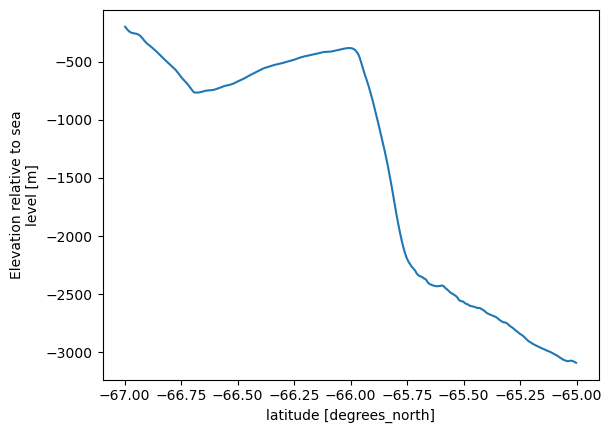

In [7]:
elevation.sel(longitude=slice(143,145)).mean('longitude').plot()

In [8]:
meop_mertz=MEOP(extent=extent)
#df1=meop_mertz.load_profiles()

In [9]:
meop_mertz.load_profiles_for_spira()

 14%|█▍        | 12/84 [00:11<00:39,  1.82it/s]

100%|██████████| 84/84 [01:22<00:00,  1.02it/s]


In [10]:
meop_mertz.ds['elev']=elevation.interp({'latitude':meop_mertz.ds.lat,'longitude':meop_mertz.ds.lon})

In [11]:
#find seals which travel a decent (>1 degree) meridional distance
mdlmax = meop_mertz.ds.reset_coords().groupby('profile_code').max().lat
mdlmin = meop_mertz.ds.reset_coords().groupby('profile_code').min().lat
mdemax = meop_mertz.ds.reset_coords().groupby('profile_code').max().elev
mdemin= meop_mertz.ds.reset_coords().groupby('profile_code').min().elev

longg = mdlmax.profile_code.where(((mdlmax - mdlmin) > 0.6) & ((mdemax - mdemin) > 800), drop=True)

/home/users/eejco/miniforge3/envs/sha-env/lib/python3.14/site-packages/xarray/structure/concat.py:673: UserWarning: No index created for dimension profile_code because variable profile_code is not a coordinate. To create an index for profile_code, please first call `.set_coords('profile_code')` on this object.
  ds.expand_dims(dim_name, create_index_for_new_dim=create_index_for_new_dim)
/home/users/eejco/miniforge3/envs/sha-env/lib/python3.14/site-packages/xarray/structure/concat.py:673: UserWarning: No index created for dimension profile_code because variable profile_code is not a coordinate. To create an index for profile_code, please first call `.set_coords('profile_code')` on this object.
  ds.expand_dims(dim_name, create_index_for_new_dim=create_index_for_new_dim)
/home/users/eejco/miniforge3/envs/sha-env/lib/python3.14/site-packages/xarray/structure/concat.py:673: UserWarning: No index created for dimension profile_code because variable profile_code is not a coordinate. To create

In [12]:
longg

<xarray.DataArray 'profile_code' (profile_code: 10)> Size: 80B
array(['ct111-665-13', 'ct64-M052-09', 'ct84-744-12', 'ft33-791-22',
       'wd10-681-17', 'wd12-144-19', 'wd12-145-19', 'wd20-546-19',
       'wd3-CTD2-07', 'wd3-CTD3-07'], dtype=object)
Coordinates:
  * profile_code  (profile_code) object 80B 'ct111-665-13' ... 'wd3-CTD3-07'

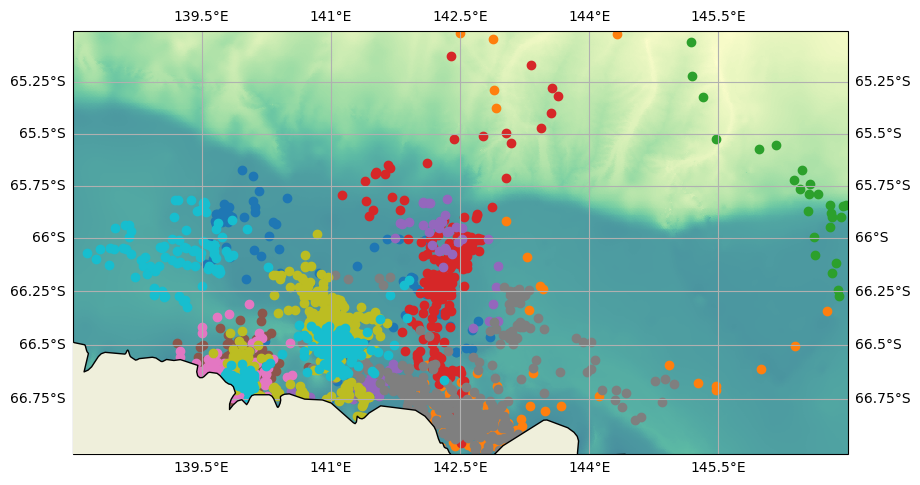

In [13]:
fig,ax=plt.subplots(figsize=(10,8),subplot_kw={'projection':ccrs.Mercator()})
pfns.sp(ax,elevation,extent=extent,cmap=cmocean.cm.deep,land_zorder=3)
for platform in longg:
    dff = meop_mertz.ds.where(meop_mertz.ds.profile_code == platform,drop=True)
    ax.scatter(dff.lon,dff.lat,transform=ccrs.PlateCarree(),label=platform.item())
#ax.legend()

In [14]:
ds = meop_mertz.ds
ds['asal'] = gsw.conversions.SA_from_SP(ds.psal,ds.pres,145,ds.lat)
ds['ctemp'] = gsw.conversions.CT_from_t(ds.asal,ds.temp,ds.pres)
ds['rho'] = gsw.density.rho(ds.asal,ds.ctemp,ds.pres)
ds['sigma0'] = gsw.density.sigma0(ds.asal,ds.ctemp)
ds['month'] = ds.time.dt.month

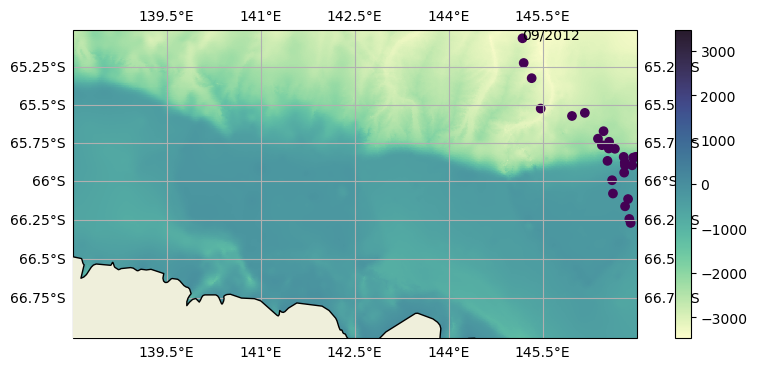

In [15]:
pc = 'ct84-744-12'#'ct64-M052-09'#'ft33-791-22'
dspc = ds.where(ds.profile_code == pc,drop=True)
fig,ax=plt.subplots(figsize=(10,4),subplot_kw={'projection':ccrs.Mercator()})
im=pfns.sp(ax,elevation,extent=extent,cmap=cmocean.cm.deep)
ax.scatter(dspc.lon,dspc.lat,c=dspc.month,transform=ccrs.PlateCarree(),label=platform.item())
for m in np.unique(dspc.month):
    eg = dspc.where(dspc.month==m,drop=True).isel(time=0)
    tstr = eg.time.dt.strftime("%m/%Y").item()
    ax.text(eg.lon,eg.lat,tstr,transform=ccrs.PlateCarree())
plt.colorbar(im)


In [16]:
dsm = dspc.where(dspc.month == 9,drop=True)
dsml = dsm.swap_dims({'time':'lat'}).sortby('lat')
keep = ~(np.isnan(dsml.sigma0))
x=xr.broadcast(dsml.lat,dsml.pres)[0].where(keep,drop=True).to_numpy().flatten()
y=xr.broadcast(dsml.lat,dsml.pres)[1].where(keep,drop=True).to_numpy().flatten()

Text(0.5, 1.0, 'potential density')

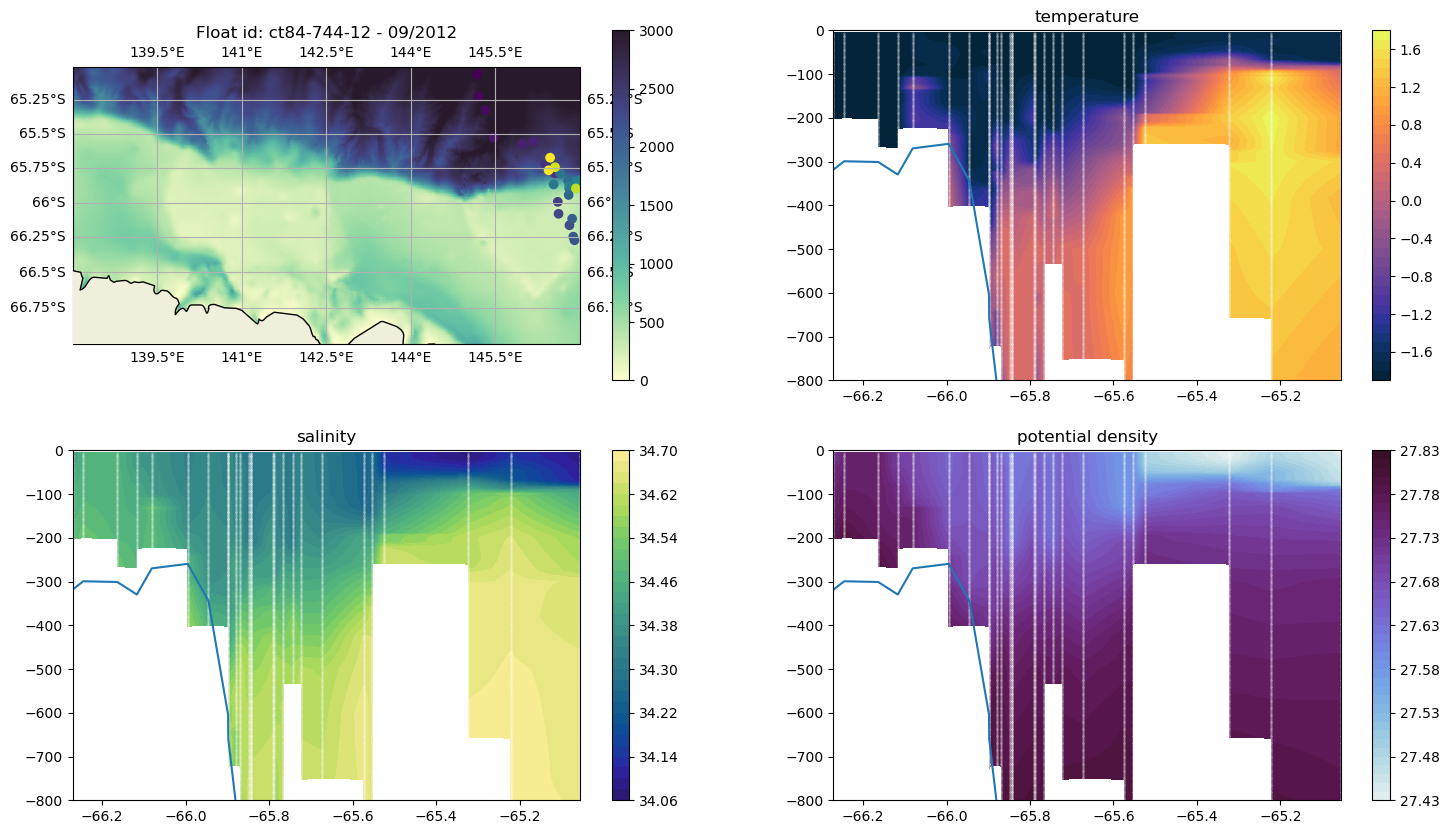

In [17]:

fig = plt.figure(figsize=(18,10))
gs = fig.add_gridspec(2,2)

et = elevation.interp({'latitude':dsml.lat,'longitude':dsml.lon})
minz = -800
levels = 40

ax = fig.add_subplot(gs[0, 0],projection=ccrs.Mercator())
im=pfns.sp(ax,-elevation,extent=extent,cmap=cmocean.cm.deep,land_zorder=3,vmin=0,vmax=3000)
ax.scatter(dsm.lon,dsm.lat,c=dsm.time,transform=ccrs.PlateCarree(),label=platform.item())
plt.colorbar(im)
ax.set_title('Float id: ' + pc + ' - ' + dsm.time[0].dt.strftime("%m/%Y").item())

ax = fig.add_subplot(gs[0, 1])
im=ax.contourf(dsml.lat,-dsml.pres,dsml.temp.T,cmap=cmocean.cm.thermal,levels=levels)#np.linspace(-1.8,0,levels),vmin=-1.8,vmax=0)
ax.plot(et.lat,et)
ax.set_ylim(minz,0)
plt.colorbar(im)
ax.scatter(x,-y,marker='.',c='w',s=0.1)
ax.set_title('temperature')

ax = fig.add_subplot(gs[1, 0])
im=ax.contourf(dsml.lat,-dsml.pres,dsml.psal.T,cmap=cmocean.cm.haline,levels=levels)#,vmin=34.2,vmax=34.7)
ax.plot(et.lat,et)
ax.set_ylim(minz,0)
plt.colorbar(im)
ax.scatter(x,-y,marker='.',c='w',s=0.1)
ax.set_title('salinity')

ax = fig.add_subplot(gs[1, 1])
im=ax.contourf(dsml.lat,-dsml.pres,dsml.sigma0.T,cmap=cmocean.cm.dense,levels=levels)#,vmin=27.5,vmax=28)
ax.plot(et.lat,et)
ax.set_ylim(minz,0)
plt.colorbar(im)
ax.scatter(x,-y,marker='.',c='w',s=0.1)
ax.set_title('potential density')


In [ ]:
month = 12
# plot all seal trails for